In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transaction_analysis.config.paths import FRAUD_DATASET_DIR, PLOTS_DIR
from transaction_analysis.data.loader import load_fraud_transactions
from transaction_analysis.eda.anomalies import anomaly_analysis
from transaction_analysis.eda.pca import run_user_pca
from transaction_analysis.eda.step.analysis import TransactionAnalysis
from transaction_analysis.eda.visualizations import (
    plot_amount_distribution,
    plot_anomalies,
    plot_correlation_heatmap,
    plot_credit_score_by_gender,
    plot_demographic_patterns,
    plot_errors_and_darkweb,
    plot_pca_biplot,
    plot_pca_clusters,
    plot_pca_fraud_overlay,
    plot_pca_scree,
    plot_time_patterns,
    plot_top_mcc,
    plot_top_states_by_amount,
    plot_transactions_over_time,
    plot_us_transaction_map,
    plot_user_transaction_distribution,
)

analysis = TransactionAnalysis(load_fraud_transactions(), output_dir=PLOTS_DIR)

analysis.print_summary_statistics()


TRANSACTION STATISTICS:
  Total transactions: 13,332
  Unique users: 1,196
  Unique cards: 2,060

  Amount statistics:
    Mean: $110.23
    Median: $69.97
    Std Dev: $213.74
    Min: $-500.00
    Max: $4,978.45

USER STATISTICS:
  Total users: 1,196
  Avg txns per user: 11.1
  Median txns per user: 9.0
  Max txns per user: 58

MERCHANT STATISTICS:
  Unique merchants: 1,090
  Top merchant txn count: 764

MCC STATISTICS:
  Unique MCC codes: 98
  Top MCC txn count: 2,251


In [3]:
analysis.print_top_items(n=10)


Top 10 Merchants by Transaction Count:
   1. Merchant  60569 -    764 txns,                 $  108.42 avg
   2. Merchant  27092 -    725 txns,                 $   91.17 avg
   3. Merchant  48919 -    332 txns,                 $   87.21 avg
   4. Merchant  99370 -    302 txns,                 $   74.42 avg
   5. Merchant  32858 -    289 txns,                 $   97.73 avg
   6. Merchant  76639 -    286 txns,                 $  152.09 avg
   7. Merchant  83018 -    236 txns,                 $   56.63 avg
   8. Merchant  67570 -    225 txns,                 $  103.40 avg
   9. Merchant  31893 -    214 txns,                 $  115.49 avg
  10. Merchant  34490 -    197 txns,                 $  152.46 avg

Top 10 MCC Codes by Transaction Count:
   1. MCC   5311 -  2,251 txns,                    861 customers
   2. MCC   5300 -    991 txns,                    570 customers
   3. MCC   5310 -    859 txns,                    540 customers
   4. MCC   4829 -    725 txns,                    447 

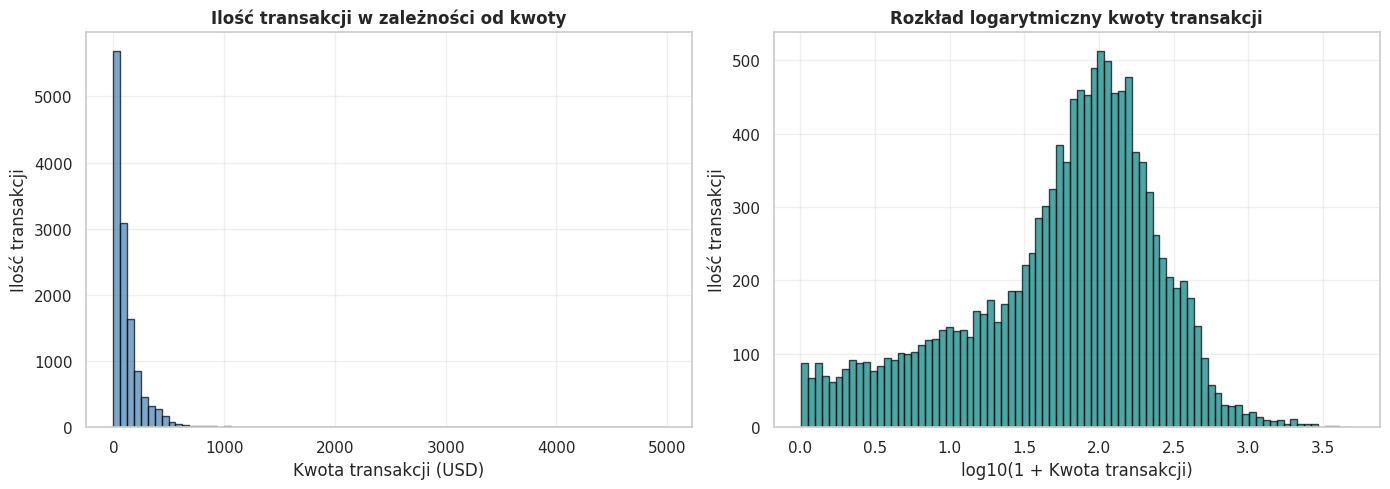

In [4]:
analysis.plot_graph(plot_amount_distribution, analysis.transactions)

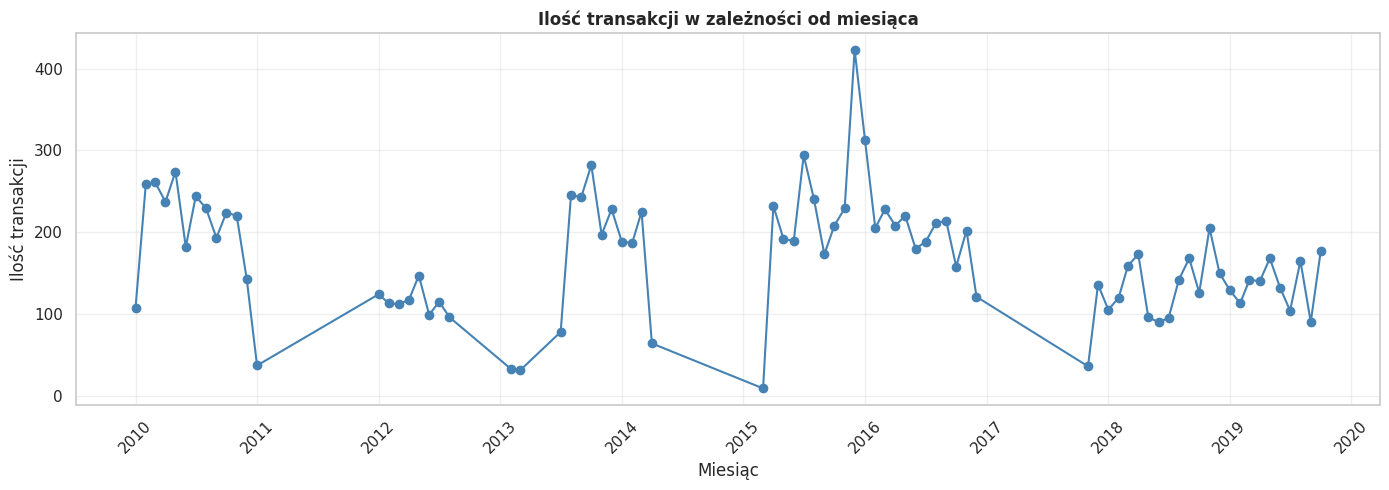

In [5]:
analysis.plot_graph(plot_transactions_over_time, analysis.transactions)

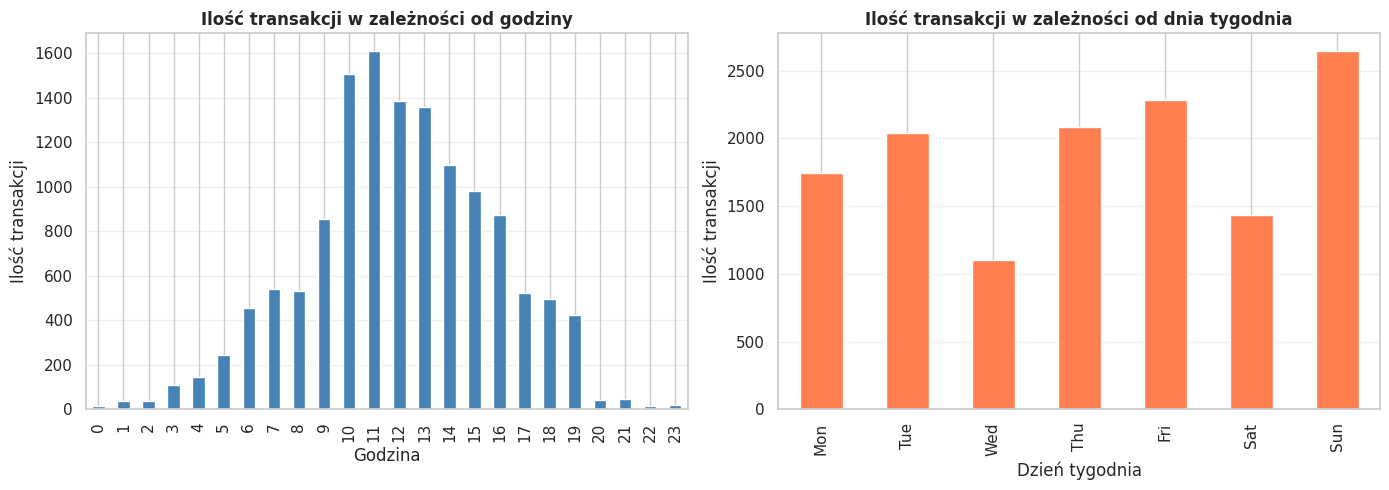

In [6]:
analysis.plot_graph(plot_time_patterns, analysis.transactions)

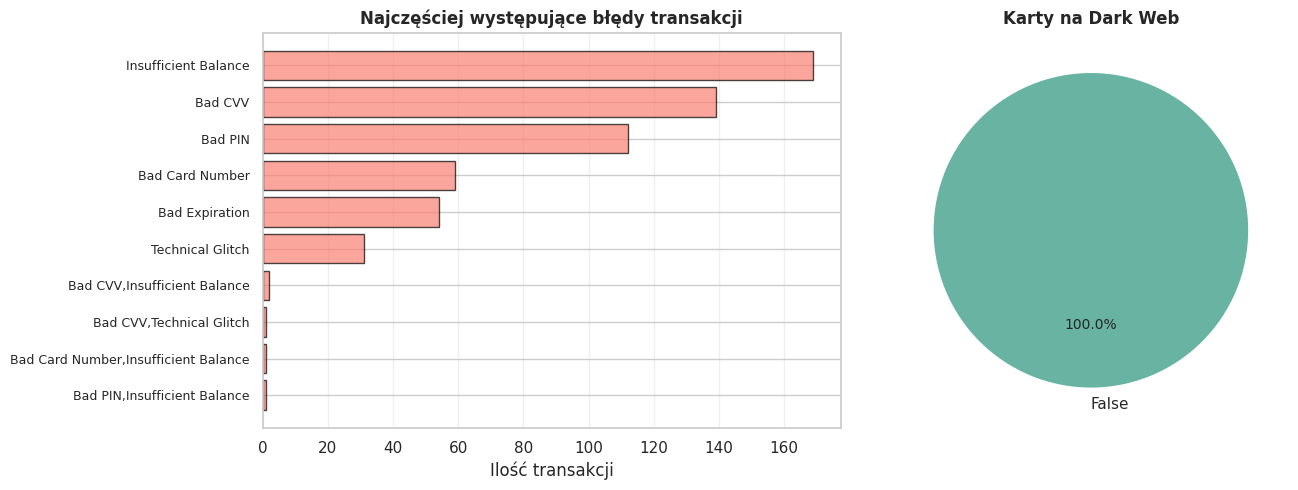

In [7]:
analysis.plot_graph(plot_errors_and_darkweb, analysis.transactions, analysis.cards)

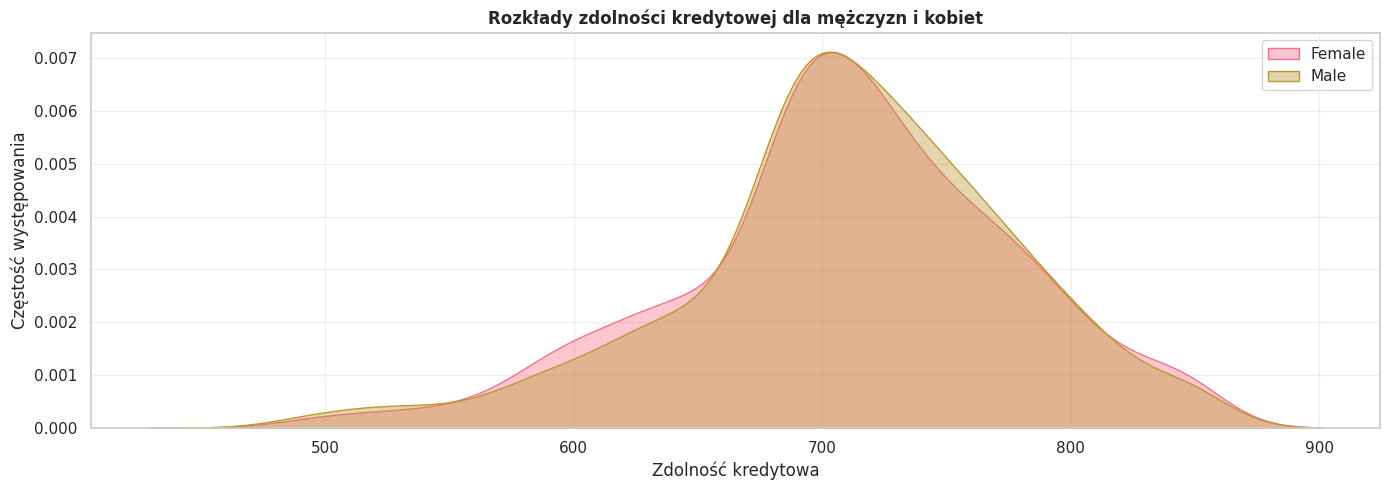

In [8]:
analysis.plot_graph(plot_credit_score_by_gender, analysis.users)

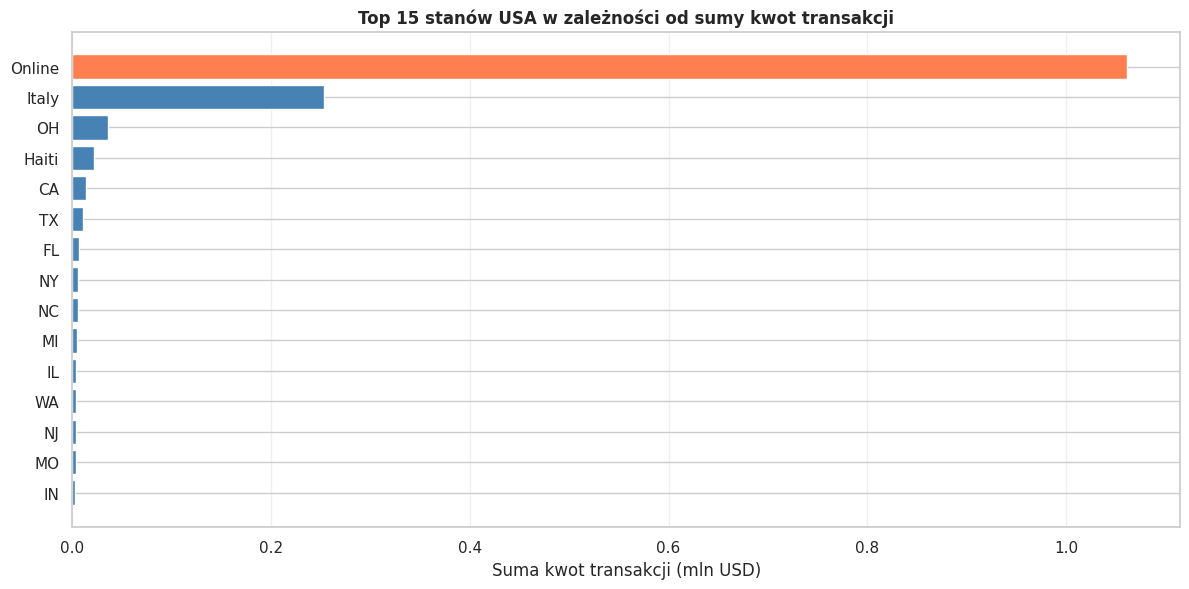

In [9]:
analysis.plot_graph(plot_top_states_by_amount, analysis.transactions, top_n=15)

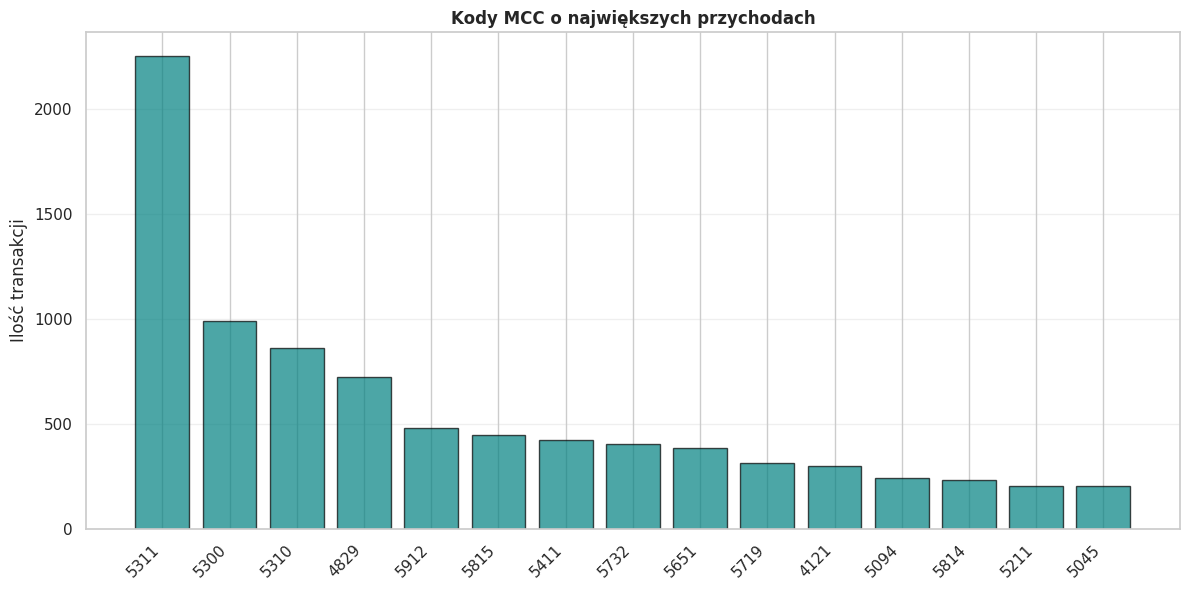

In [10]:
analysis.plot_graph(plot_top_mcc, analysis.mcc_agg, top_n=15)

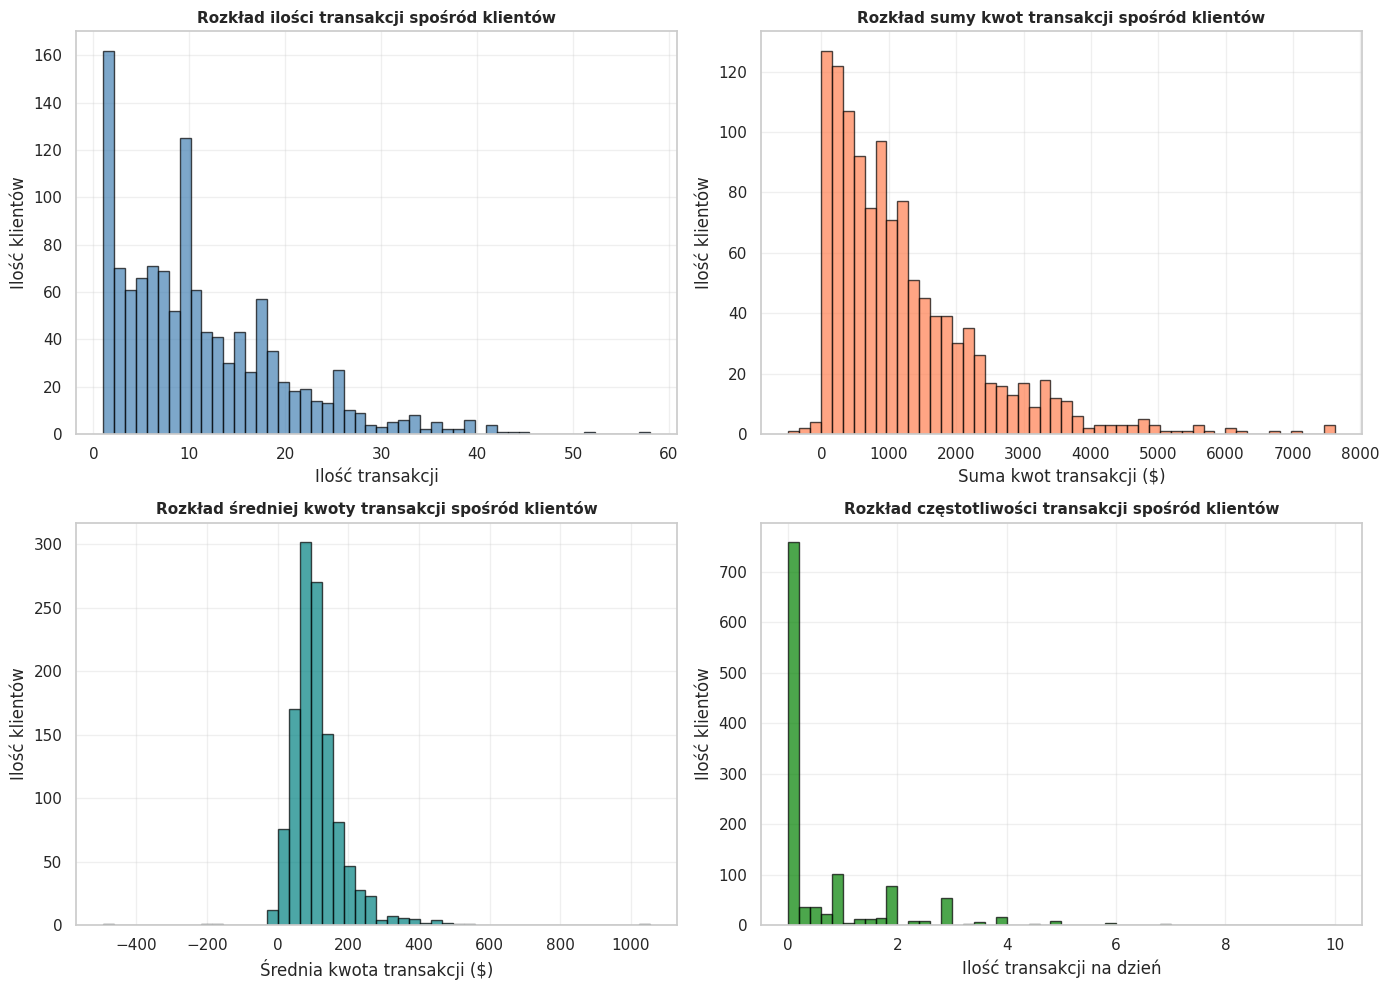

In [13]:
analysis.plot_graph(plot_user_transaction_distribution, analysis.user_agg)

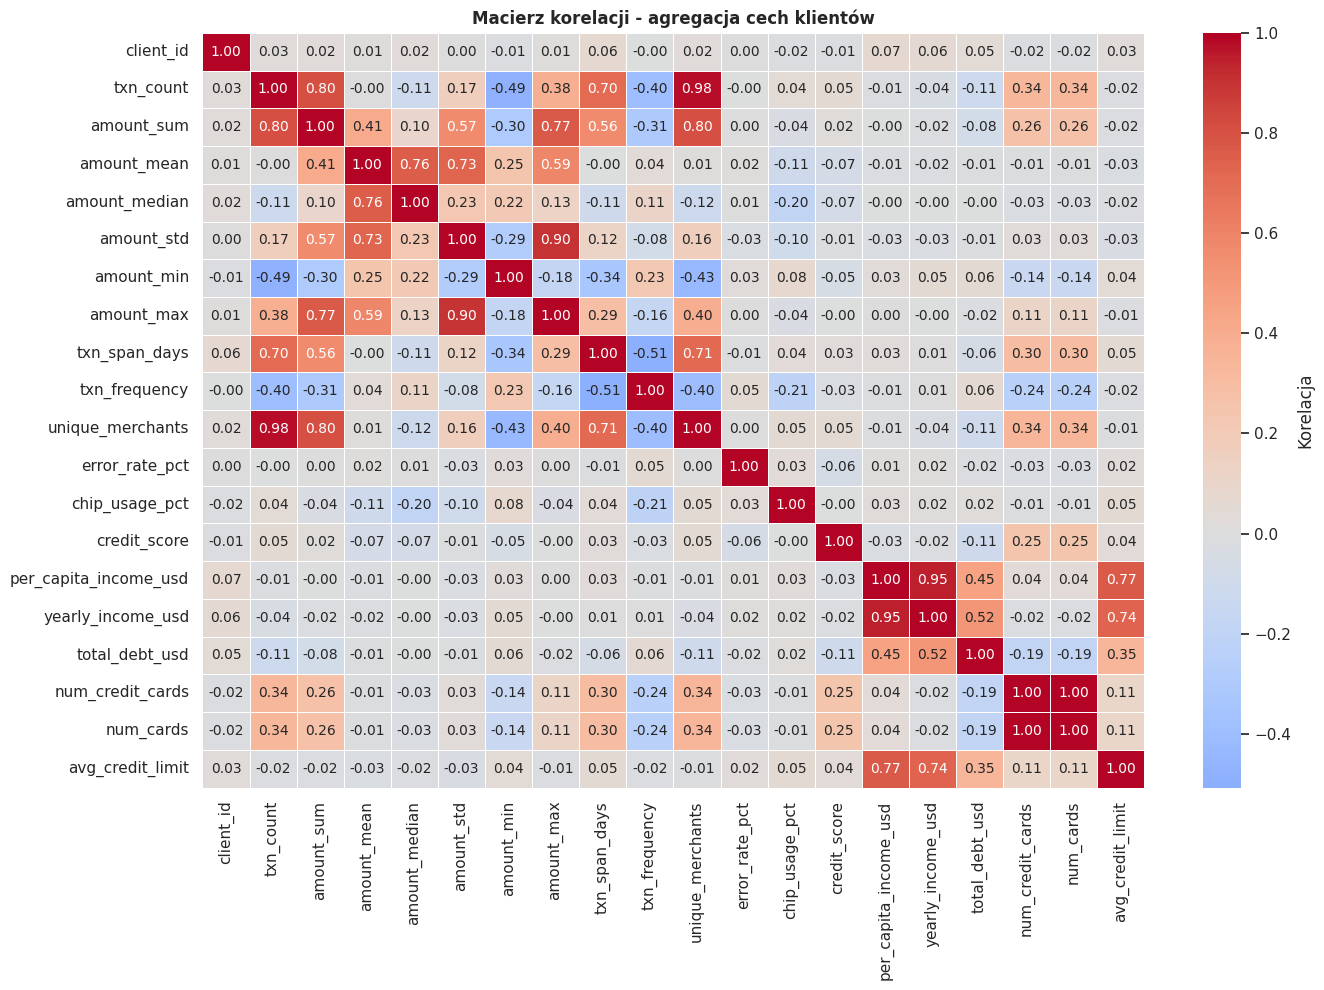

In [14]:
analysis.plot_graph(plot_correlation_heatmap, analysis.user_agg)

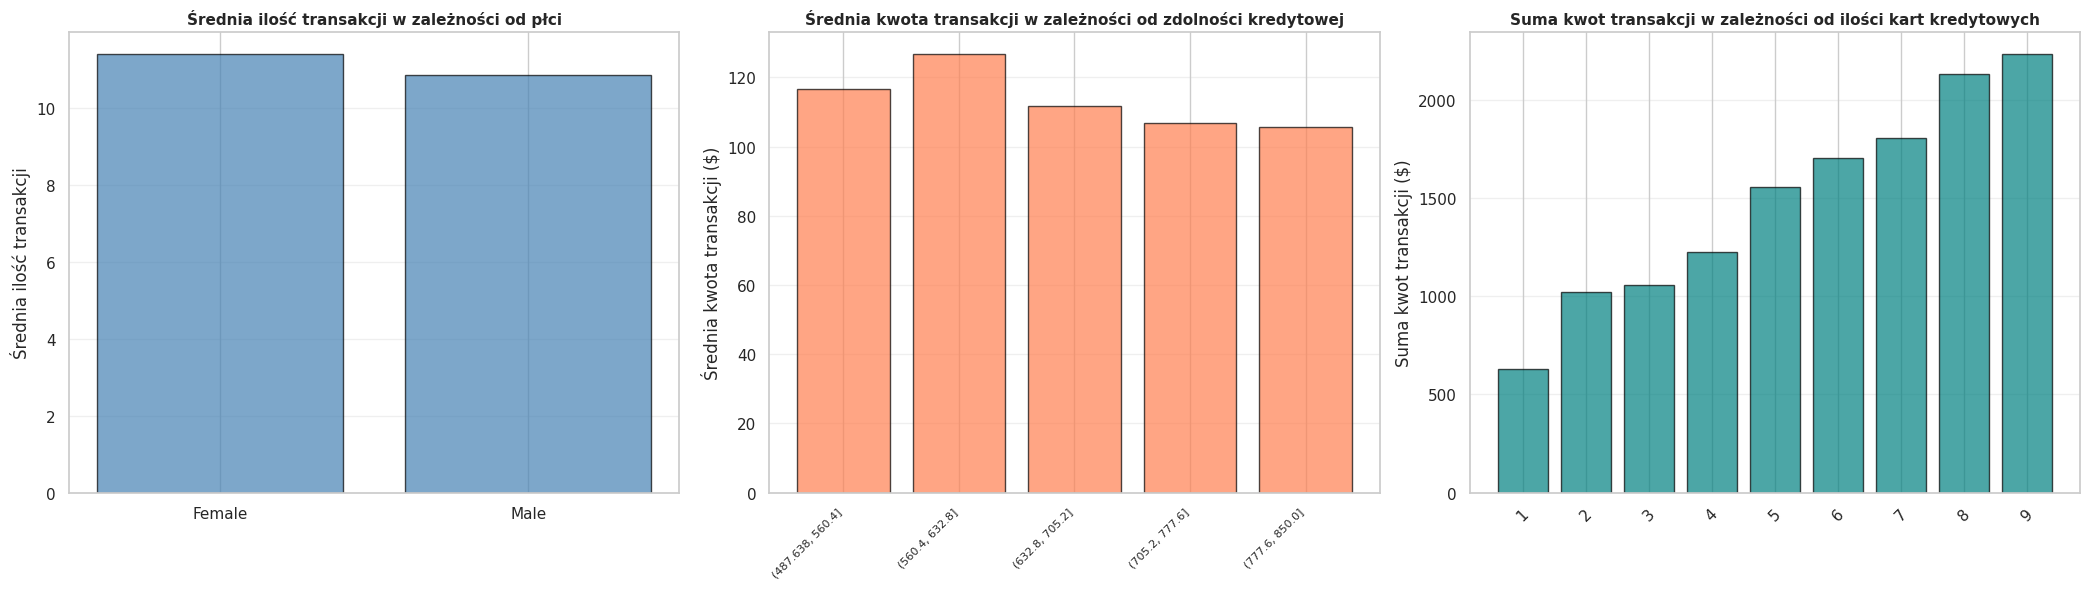

In [15]:
analysis.plot_graph(plot_demographic_patterns, analysis.user_agg)

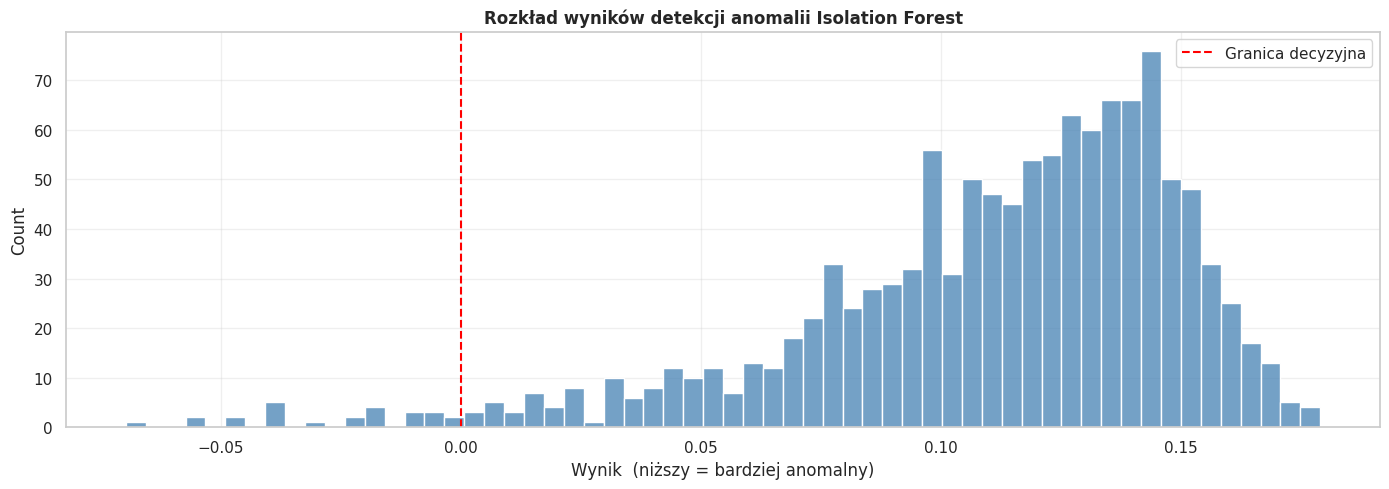

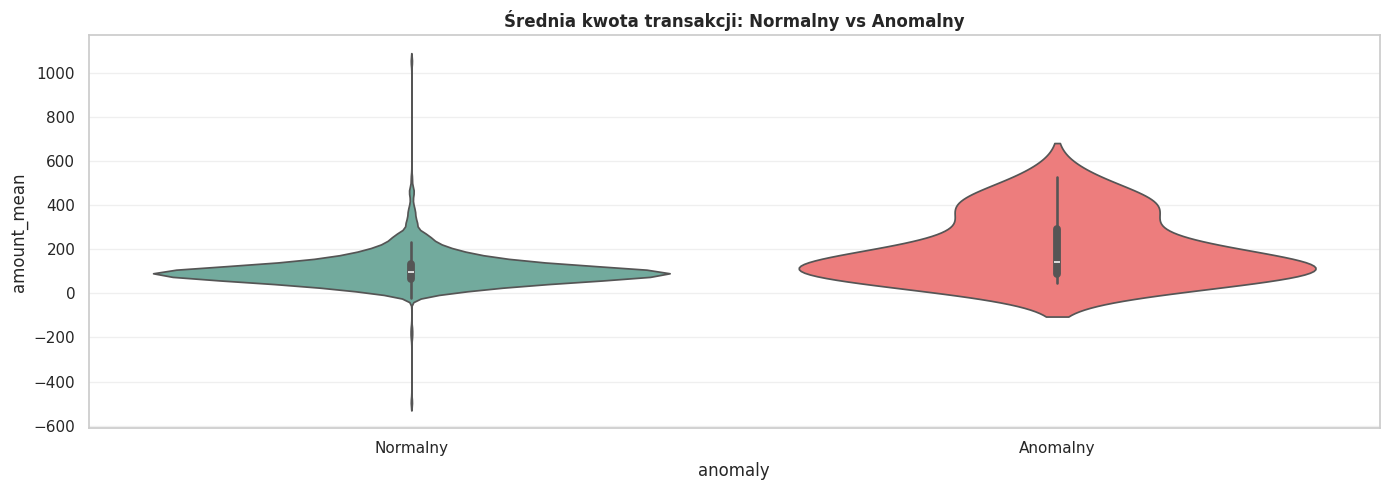

In [16]:
anomalous_user_agg, _ = anomaly_analysis(analysis.user_agg)
analysis.plot_graph(plot_anomalies, anomalous_user_agg)

Using existing shapefiles, skipping download. Use `force=True` to re-download.


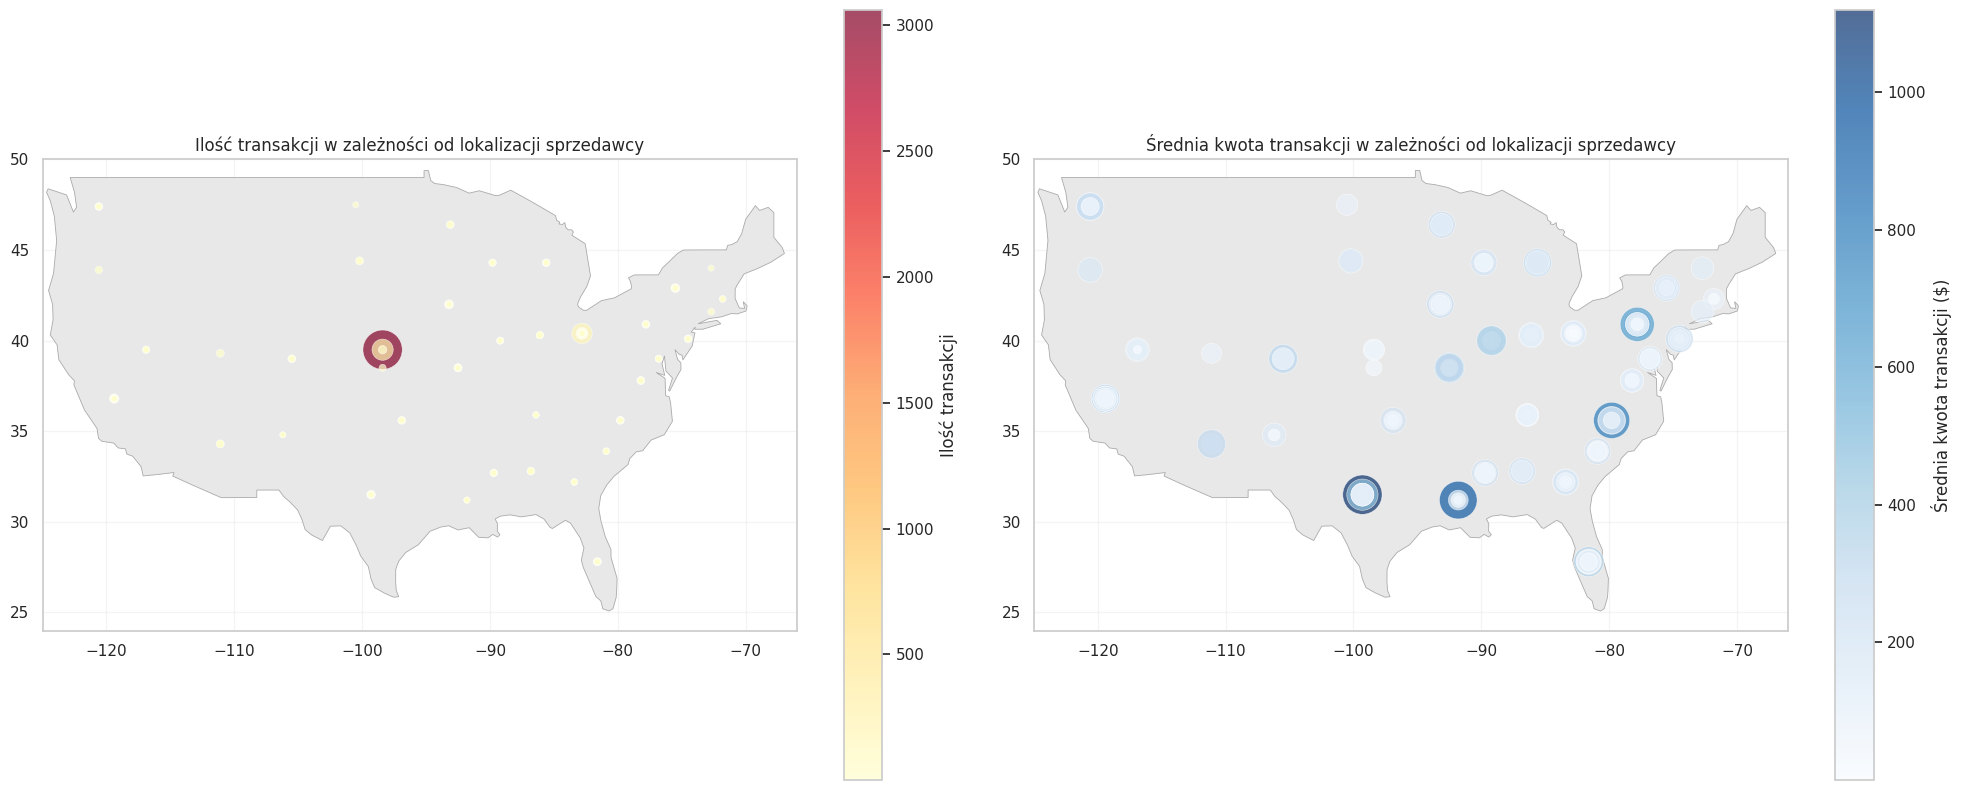

In [17]:
analysis.plot_graph(plot_us_transaction_map, analysis.transactions)

In [18]:
# User-level PCA: build a numeric feature matrix per client_id and fit PCA.
# Heavy-tailed monetary features are log1p-transformed inside run_user_pca.
import pandas as pd

fraud_labels = pd.read_parquet(FRAUD_DATASET_DIR / "cleaned" / "fraud_labels.parquet")
pca = run_user_pca(
    transactions=analysis.transactions,
    users=analysis.users,
    cards=analysis.cards,
    fraud_labels=fraud_labels,
    n_components=6,
    n_clusters=4,
)
print(f"Users: {len(pca.scores)}, features: {pca.loadings.shape[0]}")
print("Explained variance (per PC):", [f"{v:.3f}" for v in pca.explained_variance])
print(
    f"Cumulative variance (first 2 / all): {pca.explained_variance[:2].sum():.3f} / {pca.explained_variance.sum():.3f}"
)

Users: 1196, features: 29
Explained variance (per PC): ['0.199', '0.111', '0.094', '0.079', '0.070', '0.051']
Cumulative variance (first 2 / all): 0.310 / 0.604


In [19]:
# Top loadings give each axis a name.

top_pcs = pd.DataFrame(
    {pc: pca.loadings[pc].abs().sort_values(ascending=False).head(6).index.tolist() for pc in pca.loadings.columns}
)
top_pcs

,PC1,PC2,PC3,PC4,PC5,PC6
0,unique_mcc,total_credit_limit,yearly_income_usd,share_online,share_chip,share_swipe
1,unique_merchants,avg_credit_limit,per_capita_income_usd,share_chip,share_online,chip_share
2,amount_sum,num_credit_cards,avg_credit_limit,amount_median,refund_share,share_online
3,mcc_entropy,num_cards,total_debt_usd,debt_to_income,night_share,share_chip
4,txn_count,amount_mean,amount_mean,num_credit_cards,avg_card_age_years,credit_score
5,amount_max,per_capita_income_usd,amount_median,num_cards,total_debt_usd,retirement_age


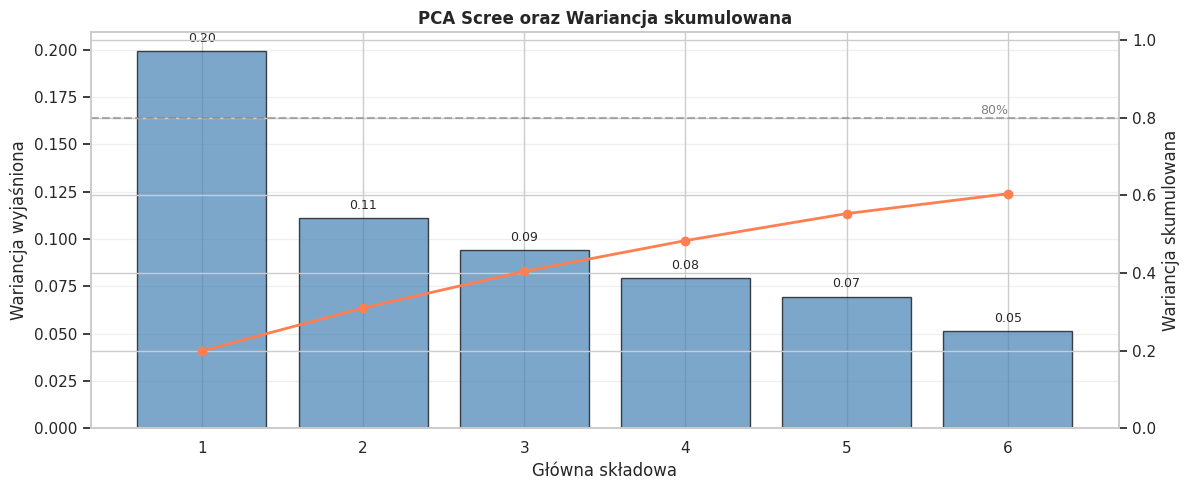

In [20]:
analysis.plot_graph(plot_pca_scree, pca.explained_variance)

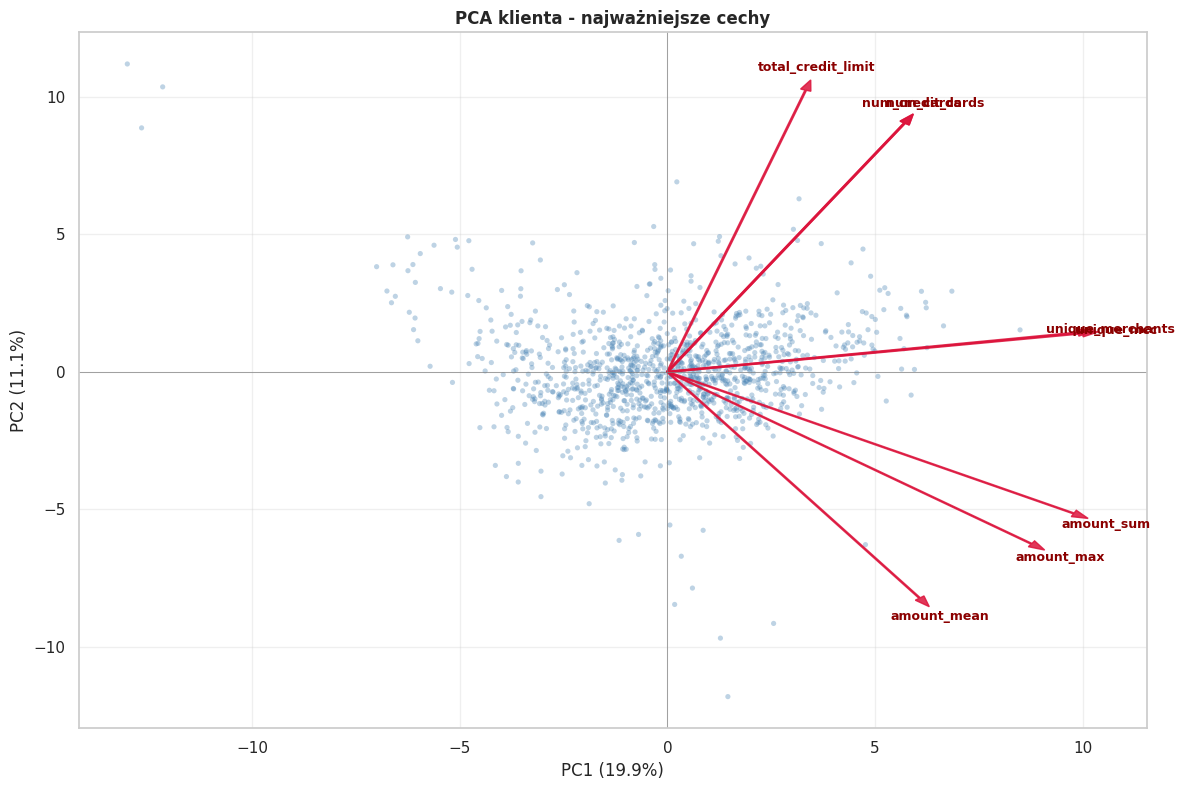

In [21]:
analysis.plot_graph(plot_pca_biplot, pca.scores, pca.loadings, pca.explained_variance)

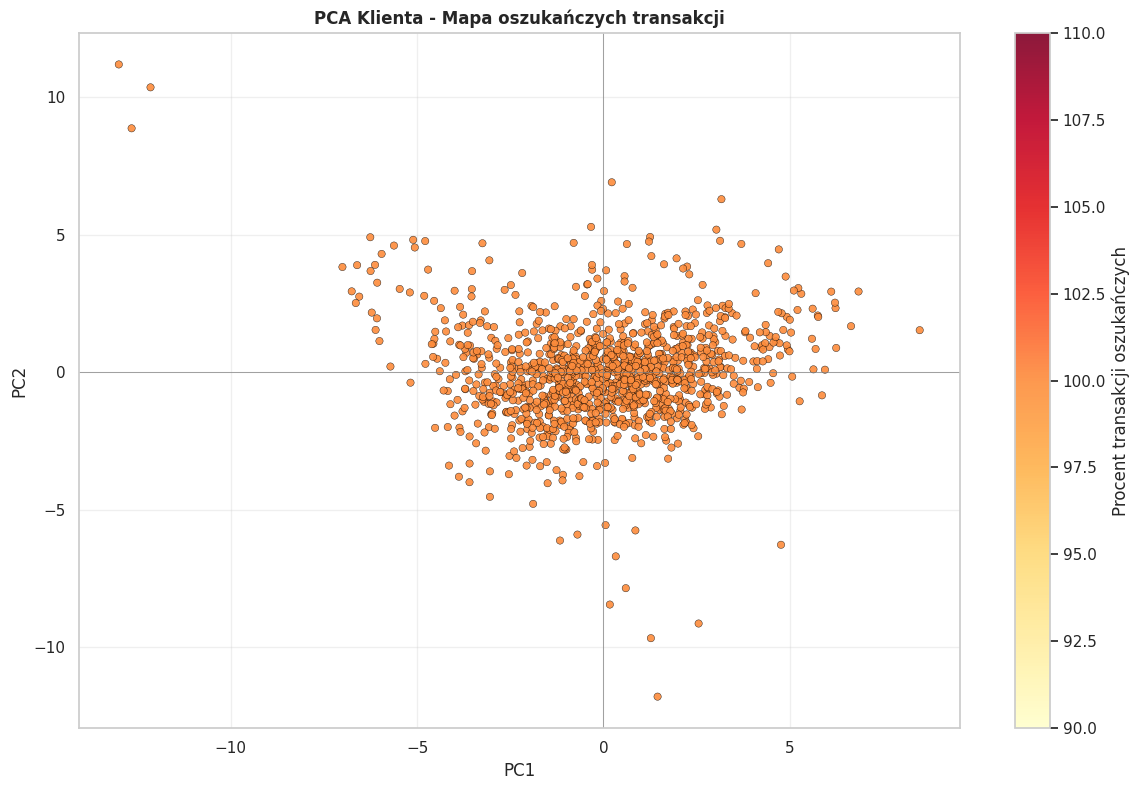

In [22]:
analysis.plot_graph(plot_pca_fraud_overlay, pca.scores, pca.fraud_rate)

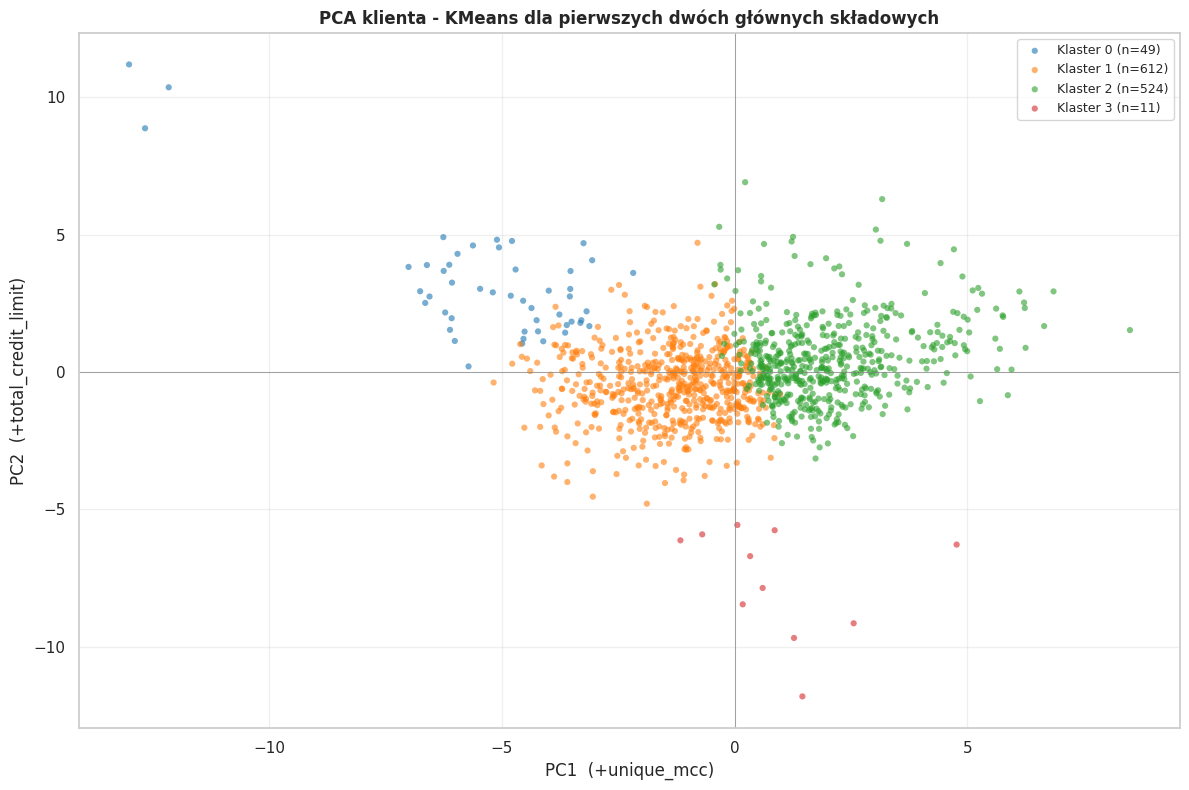

In [23]:
analysis.plot_graph(plot_pca_clusters, pca.scores, pca.clusters, pca.loadings)